<div style='background: linear-gradient(135deg, #4518af 0%, #e1fa05 100%); padding: 40px; border-radius: 15px; box-shadow: 0 10px 30px rgba(0,0,0,0.3);'>
    <h1 style='color: white; text-align: center; font-size: 48px; margin: 0; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>HELP ONG x VisionDataLab</h1>
    <h2 style='color: #e0e7ff; text-align: center; font-size: 28px; margin-top: 15px; font-weight: 300;'>Interprétation & Recommandations</h2>
    <p style='color: white; text-align: center; font-size: 16px; margin-top: 20px; opacity: 0.9;'>TP ML 2</p>
</div>

# import and Config

In [112]:
import sys, warnings
from pathlib import Path
import geopandas as gpd


root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from src.config import paths
from src.utils.country import apply_ne_mapping, COUNTRY_MAP_CLASSIC, COUNTRY_MAP_ENRICHED
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (silhouette_samples, silhouette_score,
                              calinski_harabasz_score, davies_bouldin_score,
                              adjusted_rand_score)
from sklearn.metrics.pairwise import euclidean_distances
import joblib
import shap


SEED = 42
np.random.seed(SEED)

PALETTE_K3 = ['#E74C3C', '#2ECC71', "#F2FF00"]
PALETTE_K4 = ['#E74C3C', '#2ECC71', "#EEFF00", '#F39C12']
GREY       = '#d0d0d0'

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi']     = 100

---
## Chargement des modèles et des données


In [98]:
MODEL_DIR = paths.ROOT_DIR / 'models'

# Modèles
km3 = joblib.load(MODEL_DIR / 'kmeans_k3_classique.joblib')
sc3 = joblib.load(MODEL_DIR / 'scaler_classique.joblib')
km4 = joblib.load(MODEL_DIR / 'kmeans_k4_enrichi.joblib')
sc4 = joblib.load(MODEL_DIR / 'scaler_enrichi.joblib')

# Labels et features
df3 = pd.read_csv(MODEL_DIR / 'clusters_classique_k3.csv')
df4 = pd.read_csv(MODEL_DIR / 'clusters_enrichi_k4.csv')

FEAT_K3 = ['life_expec', 'child_mort_log', 'total_fer', 'gdpp_log',
           'health', 'inflation_log', 'exports_log', 'imports_log']

FEAT_K4 = ['physicians_per_1000', 'hiv_prevalence_log', 'life_expec',
           'child_mort_log', 'vaccination_dpt_log', 'gdpp_log',
           'inflation_log', 'social_undernourishment_log',
           'social_poverty_2_15_log', 'social_schooling_log',
           'security_apparatus', 'group_grievance',
           'refugees_idps', 'external_intervention']

K3, K4 = 3, 4
labels3  = df3['cluster'].values
labels4  = df4['cluster'].values


X3       = df3[FEAT_K3].values
X3_sc    = sc3.transform(X3)
X4       = df4[FEAT_K4].values
X4_sc    = sc4.transform(X4)

# DataFrames avec index pays 
X3_df = pd.DataFrame(X3_sc, columns=FEAT_K3, index=df3['country'].values)
X4_df = pd.DataFrame(X4_sc, columns=FEAT_K4, index=df4['country'].values)

print(f'Dataset classique  : {df3.shape[0]} pays, {len(FEAT_K3)} variables')
print(f'Dataset enrichi    : {df4.shape[0]} pays, {len(FEAT_K4)} variables')

Dataset classique  : 167 pays, 8 variables
Dataset enrichi    : 167 pays, 14 variables


In [99]:
# Profils bruts (valeurs moyennes dans l'espace original)
m3_raw = pd.DataFrame(X3, columns=FEAT_K3)
m3_raw['cluster'] = labels3
m3_raw = m3_raw.groupby('cluster')[FEAT_K3].mean()

m4_raw = pd.DataFrame(X4, columns=FEAT_K4)
m4_raw['cluster'] = labels4
m4_raw = m4_raw.groupby('cluster')[FEAT_K4].mean()

# Profils standardisés
m3_std = pd.DataFrame(X3_sc, columns=FEAT_K3)
m3_std['cluster'] = labels3
m3_std = m3_std.groupby('cluster')[FEAT_K3].mean()

m4_std = pd.DataFrame(X4_sc, columns=FEAT_K4)
m4_std['cluster'] = labels4
m4_std = m4_std.groupby('cluster')[FEAT_K4].mean()

#  Identification des clusters à partir des profils 

# le cluster au gdpp_log le plus élevé = Développés
#        celui à la mortalité infantile la plus élevée = Prioritaires
#        le troisième = Intermédiaires
dev3  = m3_raw['gdpp_log'].idxmax()
pri3  = m3_raw['child_mort_log'].idxmax()
int3  = [k for k in range(K3) if k not in [dev3, pri3]][0]
NAMES_K3 = {dev3: 'Développés', int3: 'Intermédiaires', pri3: 'Prioritaires'}
COLORS_K3 = {k: PALETTE_K3[i] for i, k in enumerate(sorted(NAMES_K3))}

#  : hiv_prevalence_log max = Crise VIH
#        security_apparatus max = États fragiles
#        gdpp_log max = Développés stables
#        le quatrième = Intermédiaires vulnérables
hiv4  = m4_raw['hiv_prevalence_log'].idxmax()
sec4  = m4_raw['security_apparatus'].idxmax()
dev4  = m4_raw['gdpp_log'].idxmax()
vuln4 = [k for k in range(K4) if k not in [hiv4, sec4, dev4]][0]
NAMES_K4 = {dev4: 'Développés stables', hiv4: 'Crise VIH',
            sec4: 'États fragiles', vuln4: 'Intermédiaires vulnérables'}
COLORS_K4 = {k: PALETTE_K4[i] for i, k in enumerate(sorted(NAMES_K4))}


---
# Partie I : Dataset classique 


## Heatmap des profils 

La couleur encode le score standardisé (positif = au-dessus de la moyenne mondiale, négatif = en dessous). L'annotation indique la valeur brute originale. Cette double lecture permet d'identifier à la fois le classement relatif entre clusters et les ordres de grandeur .

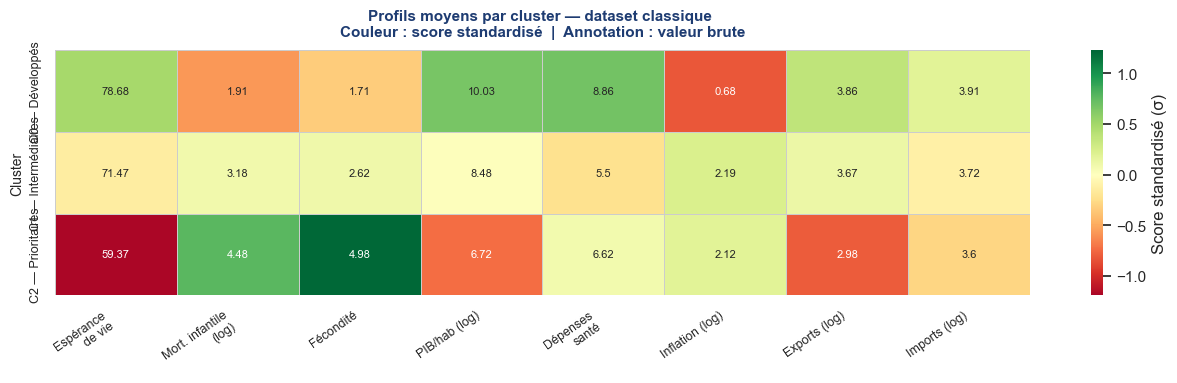

In [100]:
LABELS_K3 = {
    'life_expec':     'Espérance\nde vie',
    'child_mort_log': 'Mort. infantile\n(log)',
    'total_fer':      'Fécondité',
    'gdpp_log':       'PIB/hab (log)',
    'health':         'Dépenses\nsanté',
    'inflation_log':  'Inflation (log)',
    'exports_log':    'Exports (log)',
    'imports_log':    'Imports (log)',
}

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    m3_std.rename(columns=LABELS_K3),
    annot=m3_raw.rename(columns=LABELS_K3).round(2),
    fmt='g', cmap='RdYlGn', center=0,
    linewidths=0.4, linecolor='#cccccc',
    cbar_kws={'label': 'Score standardisé (σ)'},
    ax=ax, annot_kws={'size': 8}
)
ax.set_title(
    'Profils moyens par cluster — dataset classique \n'
    'Couleur : score standardisé  |  Annotation : valeur brute',
    fontsize=11, fontweight='bold', color='#1e3c72', pad=10
)
ax.set_ylabel('Cluster', fontsize=10)
ax.set_xlabel('')
tick_labels = [f'C{k} — {NAMES_K3[k]}' for k in sorted(NAMES_K3)]
ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## Diagramme radar 

Les valeurs sont normalisées dans [0, 1] pour permettre la comparaison visuelle sur toutes les dimensions simultanément. L'interprétation quantitative reste celle de la heatmap ci-dessus.

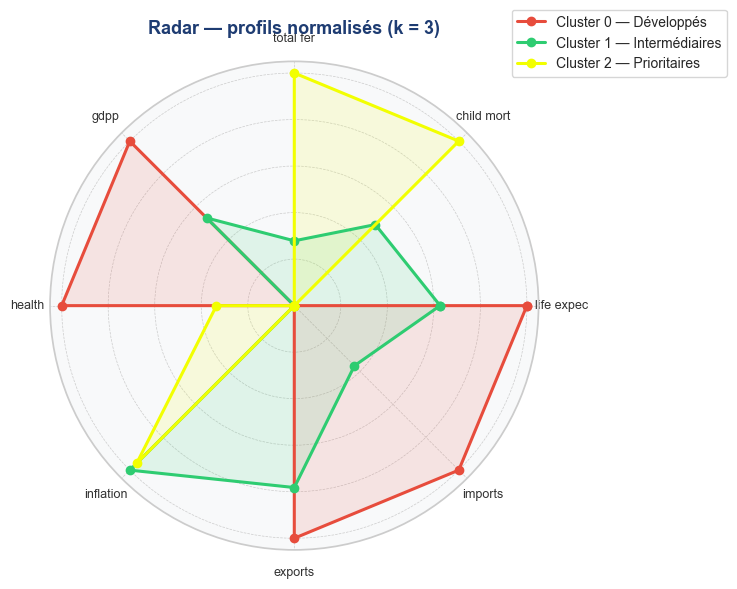

In [101]:
m3_norm = (m3_raw - m3_raw.min()) / (m3_raw.max() - m3_raw.min())
labels_r3 = [v.replace('_log', '').replace('_', ' ') for v in FEAT_K3]

N3 = len(FEAT_K3)
ang3 = np.linspace(0, 2 * np.pi, N3, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')

for k in sorted(NAMES_K3):
    vals = m3_norm.loc[k].tolist() + [m3_norm.loc[k].iloc[0]]
    ax.plot(ang3, vals, 'o-', linewidth=2.2, color=COLORS_K3[k],
            label=f'Cluster {k} — {NAMES_K3[k]}')
    ax.fill(ang3, vals, alpha=0.12, color=COLORS_K3[k])

ax.set_xticks(ang3[:-1])
ax.set_xticklabels(labels_r3, size=9, color='#333')
ax.set_yticklabels([])
ax.set_title('Radar — profils normalisés (k = 3)',
             size=13, fontweight='bold', color='#1e3c72', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.40, 1.12), fontsize=10)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## Silhouette individuelle

Le coefficient de silhouette *s(i)* ∈ [−1, 1] mesure la qualité d'assignation de chaque pays. Un score proche de 1 indique une appartenance nette ; proche de 0, une position frontière ; négatif, une probable mauvaise assignation. Les pays en zone limite sont listés ci-dessous , ils méritent une analyse complémentaire.

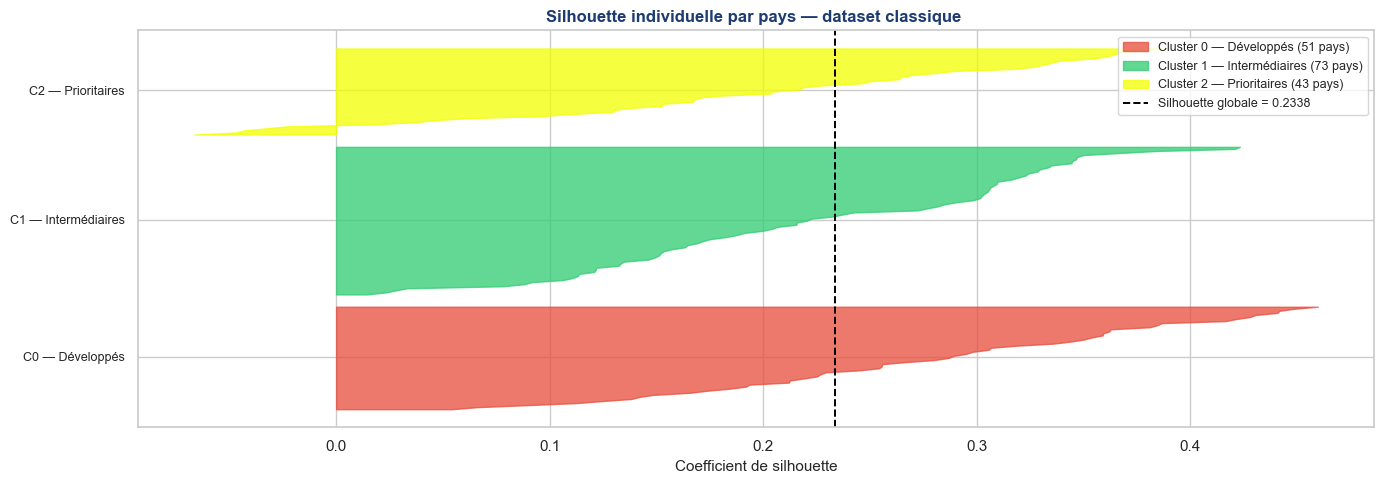

Pays en zone limite (silhouette < 0.05) : 12


,pays,cluster,label,silhouette
0,South Africa,2,Prioritaires,-0.066441
1,Yemen,2,Prioritaires,-0.046928
2,Tajikistan,2,Prioritaires,-0.043276
3,"Micronesia, Fed. Sts.",2,Prioritaires,-0.033195
4,Nepal,2,Prioritaires,-0.023074
5,Grenada,1,Intermédiaires,0.014263
6,Angola,2,Prioritaires,0.017006
7,Moldova,1,Intermédiaires,0.023511
8,Uruguay,1,Intermédiaires,0.028027
9,Chile,1,Intermédiaires,0.033266


In [102]:
sil3_samples = silhouette_samples(X3_sc, labels3)
sil3_global  = silhouette_score(X3_sc, labels3)

fig, ax = plt.subplots(figsize=(14, 5))
y_lo = 0
ticks = []
for k in sorted(NAMES_K3):
    sil_k = np.sort(sil3_samples[labels3 == k])
    n_k   = len(sil_k)
    ax.fill_betweenx(np.arange(y_lo, y_lo + n_k), 0, sil_k,
                     alpha=0.75, color=COLORS_K3[k],
                     label=f'Cluster {k} — {NAMES_K3[k]} ({n_k} pays)')
    ticks.append(y_lo + n_k / 2)
    y_lo += n_k + 5

ax.axvline(sil3_global, color='black', linestyle='--', linewidth=1.4,
           label=f'Silhouette globale = {sil3_global:.4f}')
ax.set_yticks(ticks)
ax.set_yticklabels([f'C{k} — {NAMES_K3[k]}' for k in sorted(NAMES_K3)], fontsize=9)
ax.set_xlabel('Coefficient de silhouette', fontsize=11)
ax.set_title('Silhouette individuelle par pays — dataset classique ',
             fontsize=12, fontweight='bold', color='#1e3c72')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

bl3 = pd.DataFrame({'pays': df3['country'].values,
                    'cluster': labels3, 'label': [NAMES_K3[k] for k in labels3],
                    'silhouette': sil3_samples})
bl3 = bl3[bl3['silhouette'] < 0.05].sort_values('silhouette').reset_index(drop=True)
print(f'Pays en zone limite (silhouette < 0.05) : {len(bl3)}')
if len(bl3):
    display(bl3)

## Pays représentatifs et périphériques

Les représentants (plus proches du centroïde) incarnent le profil moyen du cluster. Les périphériques (plus éloignés) sont les cas les plus ambigus, souvent au carrefour de deux groupes.

In [103]:
centroids3 = km3.cluster_centers_
dist3 = euclidean_distances(X3_sc, centroids3)

df3_pays = df3[['country']].copy()
df3_pays['cluster']        = labels3
df3_pays['dist_centroide'] = [dist3[i, labels3[i]] for i in range(len(labels3))]
df3_pays['silhouette']     = sil3_samples


In [104]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. Marquage des types de pays au sein de chaque cluster
def marquer_typologie(group):
    group = group.sort_values('dist_centroide')
    group['statut'] = 'Intermédiaire'
    # Les 5 plus proches du centre
    group.iloc[:5, group.columns.get_loc('statut')] = 'Représentant'
    # Les 5 plus éloignés
    group.iloc[-5:, group.columns.get_loc('statut')] = 'Périphérique'
    return group

df_final = df3_pays.groupby('cluster', group_keys=False).apply(marquer_typologie)

# 2. Création des facettes (une ligne par cluster)
clusters_sorted = sorted(NAMES_K3.keys())
fig = make_subplots(
    rows=len(clusters_sorted), cols=1,
    subplot_titles=[f"<b>Cluster {k} : {NAMES_K3[k]}</b>" for k in clusters_sorted],
    specs=[[{"type": "choropleth"}] for _ in clusters_sorted],
    vertical_spacing=0.05
)

# 3. Ajout des traces pour chaque cluster
for i, k in enumerate(clusters_sorted):
    sub_df = df_final[df_final['cluster'] == k]
    
    trace = go.Choropleth(
        locations=sub_df['country'],
        locationmode='country names',
        z=sub_df['dist_centroide'], # La couleur indique l'éloignement au centre
        colorscale=[[0, 'white'], [1, PALETTE_K3[k]]], # Dégradé vers la couleur du cluster
        colorbar_title="Dist. Centroïde",
        colorbar_x=1.02,
        colorbar_y=1 - (i * 0.35),
        colorbar_len=0.3,
        hovertext=sub_df['country'],
        hovertemplate="<b>%{hovertext}</b><br>Statut: " + sub_df['statut'] + 
                      "<br>Dist. Centroïde: %{z:.3f}<extra></extra>"
    )
    
    fig.add_trace(trace, row=i+1, col=1)

# 4. Ajustements esthétiques
fig.update_layout(
    height=1200, 
    title_text="<b>Analyse Géographique par Cluster</b><br>Intensité de couleur proportionnelle à l'éloignement (Périphérie)",
    showlegend=False
)

fig.update_geos(
    showcountries=True, 
    countrycolor="LightGrey",
    projection_type="natural earth"
)

fig.show()

## Interprétation SHAP

K-Means ne produit pas de coefficients directement interprétables. On entraîne un Random Forest supervisé sur les labels K-Meanspuis on calcule les valeurs SHAP du surrogat.

Cette approche standard en interprétabilité du clustering permet d'obtenir :
- l'**importance globale** de chaque variable 
- la **direction de la contribution** : une valeur élevée pousse-t-elle vers le cluster ou s'y oppose-t-elle ?
- une interprétation **locale pays par pays 


In [105]:
X3_sc

array([[-1.46956522,  0.78218678,  1.63549161, ...,  0.3431287 ,
        -1.5869512 ,  0.05460474],
       [ 0.27826087, -0.07430293, -0.36450839, ..., -0.10610696,
        -0.28941352,  0.17391757],
       [ 0.29565217,  0.17296896,  0.23021583, ...,  0.68802128,
         0.12079498, -0.48144263],
       ...,
       [ 0.        ,  0.09363511, -0.2206235 , ...,  0.50177094,
         0.94623624,  0.93253302],
       [-0.48695652,  0.54022963,  1.08393285, ...,  0.94221215,
        -0.20014746, -0.3451581 ],
       [-1.83478261,  0.73999196,  1.43405276, ...,  0.59643722,
         0.0723687 , -0.50537795]], shape=(167, 8))

=== MÉTRIQUES DE CLASSIFICATION ( ===
Accuracy  : 1.0000
Précision : 1.0000 (Moyenne macro)
Rappel    : 1.0000 (Moyenne macro)
F1-Score  : 1.0000 (Moyenne macro)

--- Rapport détaillé par Cluster ---
                            precision    recall  f1-score   support

    Cluster 0 (Développés)       1.00      1.00      1.00        51
Cluster 1 (Intermédiaires)       1.00      1.00      1.00        73
  Cluster 2 (Prioritaires)       1.00      1.00      1.00        43

                  accuracy                           1.00       167
                 macro avg       1.00      1.00      1.00       167
              weighted avg       1.00      1.00      1.00       167



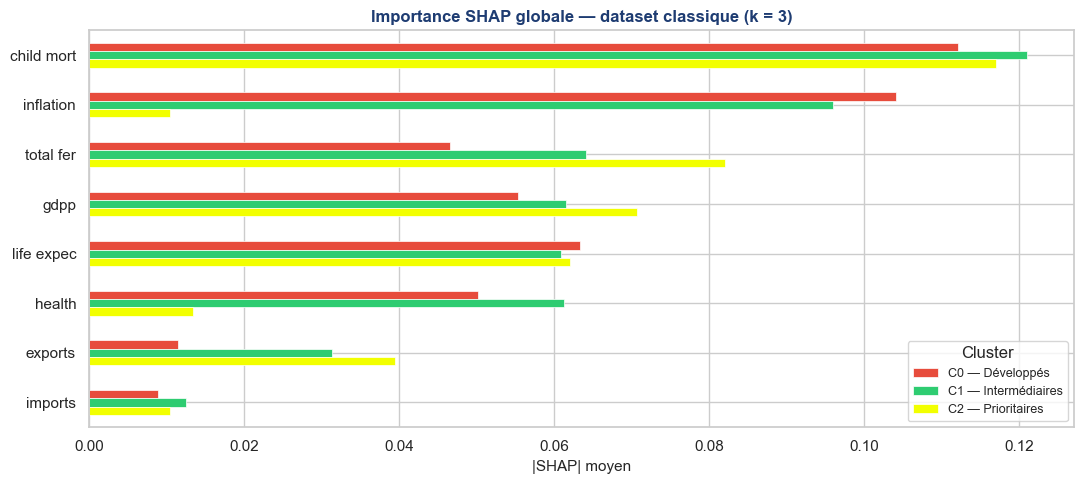


Variables les plus discriminantes (ordre décroissant) :
child_mort_log    0.1167
inflation_log     0.0702
total_fer         0.0642
gdpp_log          0.0625
life_expec        0.0621
health            0.0416
exports_log       0.0274
imports_log       0.0106


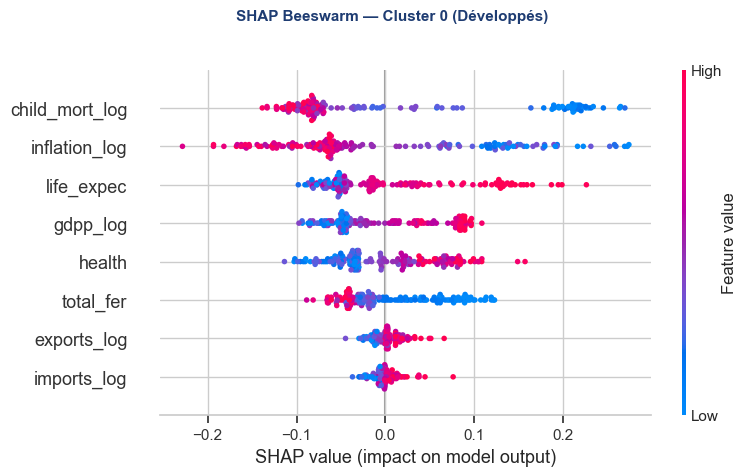

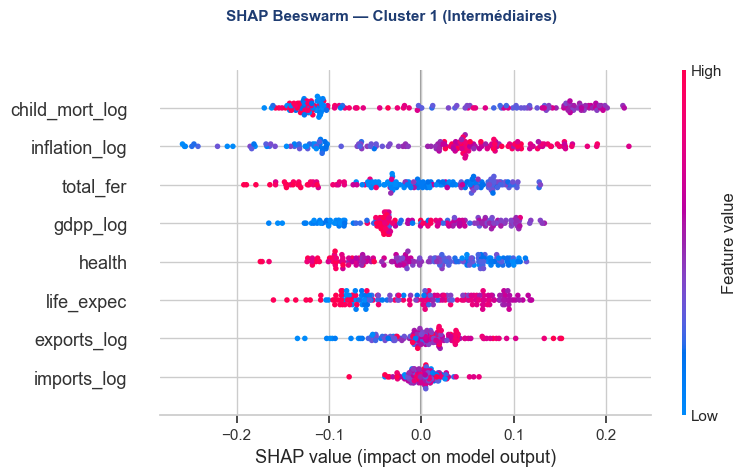

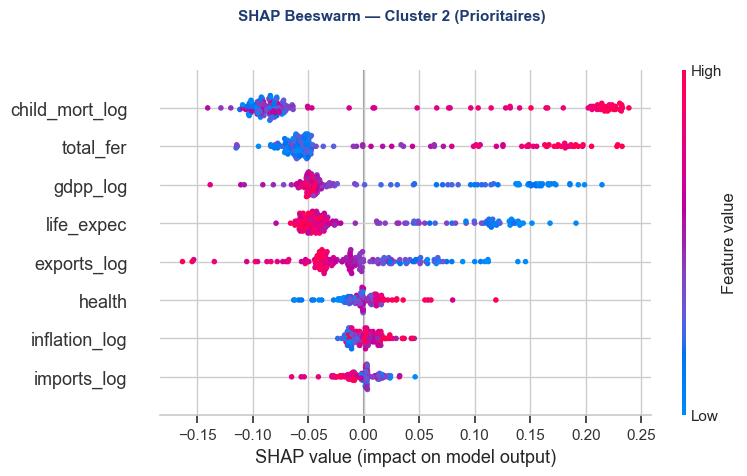

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

rf3 = RandomForestClassifier(n_estimators=300, max_depth=8,
                              random_state=SEED, n_jobs=-1)
rf3.fit(X3_sc, labels3)

# Prédictions du modèle
y_pred3 = rf3.predict(X3_sc)

# Calcul des métriques globales
acc3   = accuracy_score(labels3, y_pred3)
prec3  = precision_score(labels3, y_pred3, average='macro')
rec3   = recall_score(labels3, y_pred3, average='macro')
f1_3   = f1_score(labels3, y_pred3, average='macro')

print(f'=== MÉTRIQUES DE CLASSIFICATION ( ===')
print(f'Accuracy  : {acc3:.4f}')
print(f'Précision : {prec3:.4f} (Moyenne macro)')
print(f'Rappel    : {rec3:.4f} (Moyenne macro)')
print(f'F1-Score  : {f1_3:.4f} (Moyenne macro)')
print('\n--- Rapport détaillé par Cluster ---')

# Affichage du rapport complet avec les noms des clusters
target_names = [f"Cluster {k} ({NAMES_K3[k]})" for k in sorted(NAMES_K3)]
print(classification_report(labels3, y_pred3, target_names=target_names))


explainer3 = shap.TreeExplainer(rf3)
exp3 = explainer3(X3_df)   

# Importance globale 
shap_abs3 = np.abs(exp3.values).mean(axis=0)   # (n_features, K3)
df_imp3   = pd.DataFrame(
    shap_abs3,
    index=FEAT_K3,
    columns=[f'C{k} — {NAMES_K3[k]}' for k in sorted(NAMES_K3)]
)
df_imp3['mean'] = df_imp3.mean(axis=1)
df_imp3 = df_imp3.sort_values('mean', ascending=False)

palette_named3 = [COLORS_K3[k] for k in sorted(NAMES_K3)]

fig, ax = plt.subplots(figsize=(11, 5))
df_imp3.drop(columns='mean').rename(
    index={v: v.replace('_log', '').replace('_', ' ') for v in FEAT_K3}
).plot(kind='barh', ax=ax, color=palette_named3, edgecolor='white', linewidth=0.5)
ax.set_xlabel('|SHAP| moyen', fontsize=11)
ax.set_title('Importance SHAP globale — dataset classique (k = 3)',
             fontsize=12, fontweight='bold', color='#1e3c72')
ax.invert_yaxis()
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.show()

print('\nVariables les plus discriminantes (ordre décroissant) :')
print(df_imp3['mean'].round(4).to_string())

# -- Beeswarm par cluster -----------------------------------------------------

for k in sorted(NAMES_K3):
    exp3_k = exp3[:, :, k]
    shap.plots.beeswarm(exp3_k, max_display=8, show=False)
    plt.gcf().suptitle(f'SHAP Beeswarm — Cluster {k} ({NAMES_K3[k]})',
                       fontsize=11, fontweight='bold', color='#1e3c72', y=1.01)
    plt.tight_layout()
    plt.show()

---
# Partie II : Dataset enrichi 


## Heatmap des profils

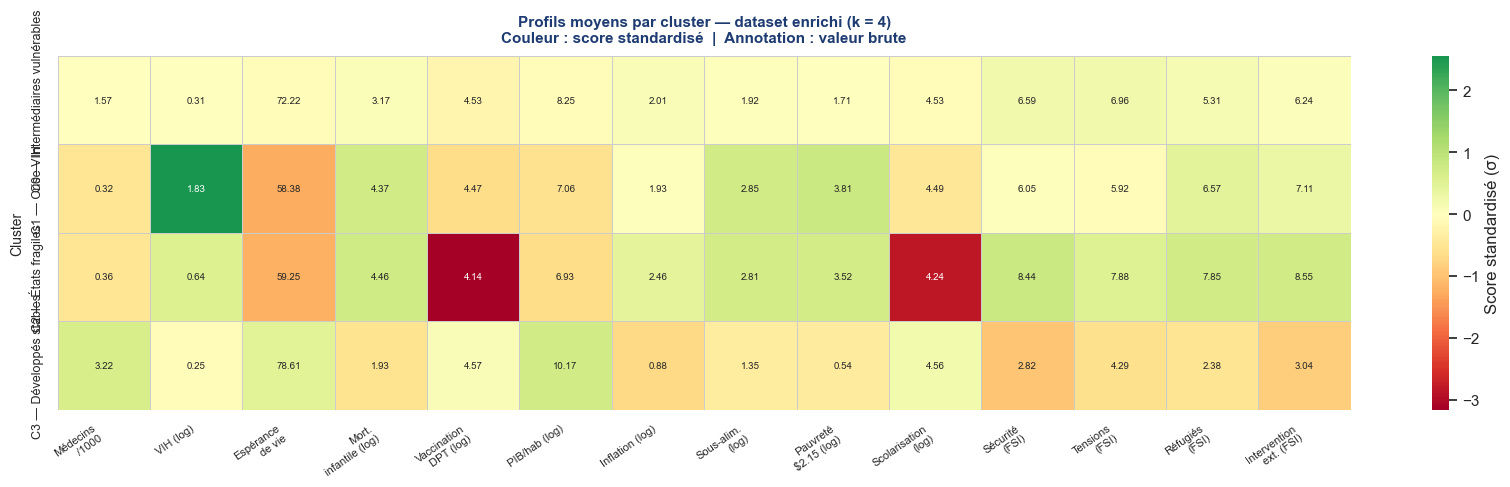

In [107]:
LABELS_K4 = {
    'physicians_per_1000':         'Médecins\n/1000',
    'hiv_prevalence_log':          'VIH (log)',
    'life_expec':                  'Espérance\nde vie',
    'child_mort_log':              'Mort.\ninfantile (log)',
    'vaccination_dpt_log':         'Vaccination\nDPT (log)',
    'gdpp_log':                    'PIB/hab (log)',
    'inflation_log':               'Inflation (log)',
    'social_undernourishment_log': 'Sous-alim.\n(log)',
    'social_poverty_2_15_log':     'Pauvreté\n$2.15 (log)',
    'social_schooling_log':        'Scolarisation\n(log)',
    'security_apparatus':          'Sécurité\n(FSI)',
    'group_grievance':             'Tensions\n(FSI)',
    'refugees_idps':               'Réfugiés\n(FSI)',
    'external_intervention':       'Intervention\next. (FSI)',
}

fig, ax = plt.subplots(figsize=(17, 5))
sns.heatmap(
    m4_std.rename(columns=LABELS_K4),
    annot=m4_raw.rename(columns=LABELS_K4).round(2),
    fmt='g', cmap='RdYlGn', center=0,
    linewidths=0.4, linecolor='#cccccc',
    cbar_kws={'label': 'Score standardisé (σ)'},
    ax=ax, annot_kws={'size': 7}
)
ax.set_title(
    'Profils moyens par cluster — dataset enrichi (k = 4)\n'
    'Couleur : score standardisé  |  Annotation : valeur brute',
    fontsize=11, fontweight='bold', color='#1e3c72', pad=10
)
ax.set_ylabel('Cluster', fontsize=10)
ax.set_xlabel('')
tick_labels4 = [f'C{k} — {NAMES_K4[k]}' for k in sorted(NAMES_K4)]
ax.set_yticklabels(tick_labels4, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## Diagramme radar 

Le radar à 14 axes permet de visualiser simultanément la structure multi-dimensionnelle des clusters. Comparer le profil *Crise VIH* (pic sur l'axe VIH) avec *États fragiles* (pic sur les axes FSI) illustre la séparation que le dataset classique ne pouvait pas capturer.

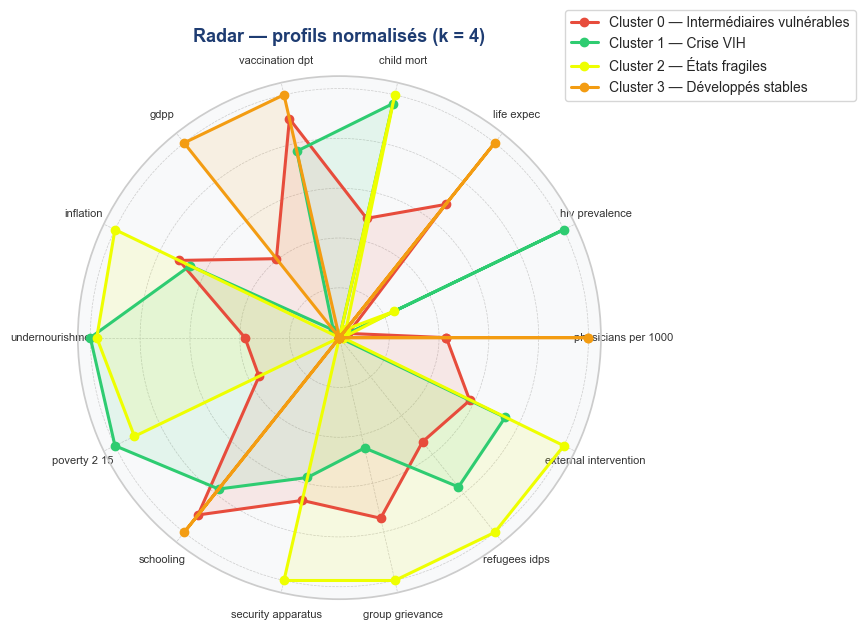

In [108]:
m4_norm = (m4_raw - m4_raw.min()) / (m4_raw.max() - m4_raw.min())
labels_r4 = [v.replace('_log', '').replace('social_', '').replace('_', ' ') for v in FEAT_K4]

N4 = len(FEAT_K4)
ang4 = np.linspace(0, 2 * np.pi, N4, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')

for k in sorted(NAMES_K4):
    vals = m4_norm.loc[k].tolist() + [m4_norm.loc[k].iloc[0]]
    ax.plot(ang4, vals, 'o-', linewidth=2.2, color=PALETTE_K4[k],
            label=f'Cluster {k} — {NAMES_K4[k]}')
    ax.fill(ang4, vals, alpha=0.10, color=PALETTE_K4[k])

ax.set_xticks(ang4[:-1])
ax.set_xticklabels(labels_r4, size=8, color='#333')
ax.set_yticklabels([])
ax.set_title('Radar — profils normalisés (k = 4)',
             size=13, fontweight='bold', color='#1e3c72', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.50, 1.14), fontsize=10)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## Silhouette individuelle 

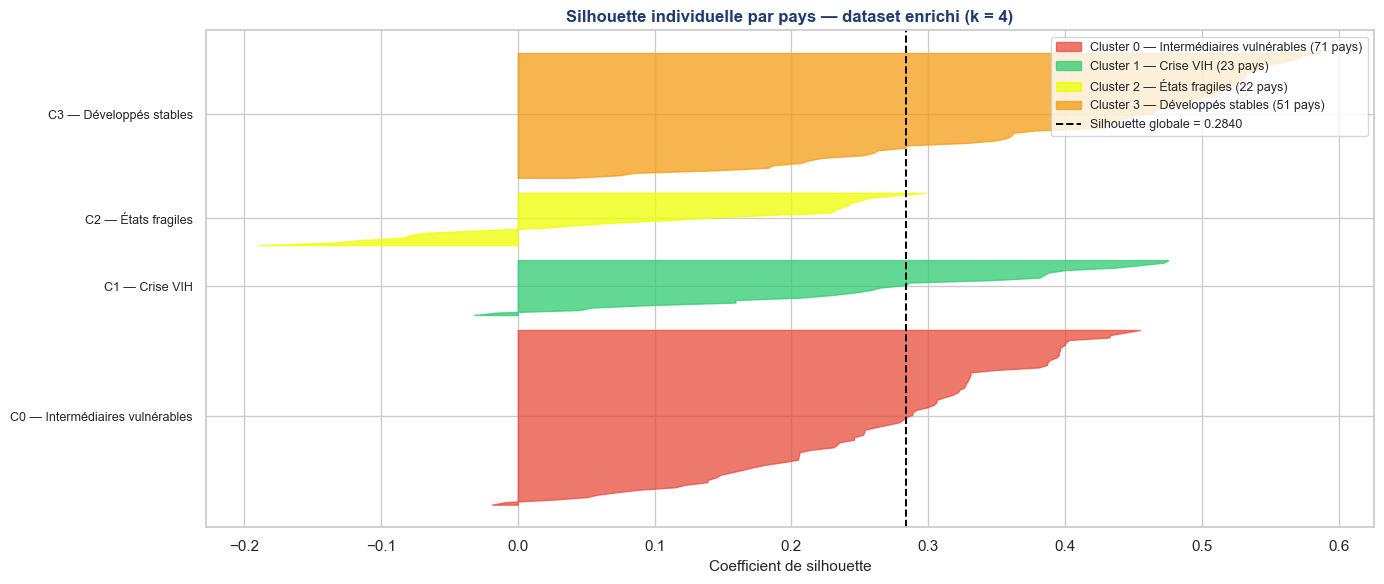

Pays en zone limite (silhouette < 0.05) : 16


,pays,cluster,label,silhouette
0,Iraq,2,États fragiles,-0.189311
1,Yemen,2,États fragiles,-0.135596
2,Burkina Faso,2,États fragiles,-0.116047
3,Madagascar,2,États fragiles,-0.083501
4,Côte d'Ivoire,2,États fragiles,-0.078976
5,Solomon Islands,2,États fragiles,-0.067041
6,Benin,1,Crise VIH,-0.032112
7,Eritrea,2,États fragiles,-0.024501
8,Montenegro,0,Intermédiaires vulnérables,-0.019002
9,Ghana,1,Crise VIH,-0.015158


In [109]:
sil4_samples = silhouette_samples(X4_sc, labels4)
sil4_global  = silhouette_score(X4_sc, labels4)

fig, ax = plt.subplots(figsize=(14, 6))
y_lo = 0
ticks = []
for k in sorted(NAMES_K4):
    sil_k = np.sort(sil4_samples[labels4 == k])
    n_k   = len(sil_k)
    ax.fill_betweenx(np.arange(y_lo, y_lo + n_k), 0, sil_k,
                     alpha=0.75, color=PALETTE_K4[k],
                     label=f'Cluster {k} — {NAMES_K4[k]} ({n_k} pays)')
    ticks.append(y_lo + n_k / 2)
    y_lo += n_k + 5

ax.axvline(sil4_global, color='black', linestyle='--', linewidth=1.4,
           label=f'Silhouette globale = {sil4_global:.4f}')
ax.set_yticks(ticks)
ax.set_yticklabels([f'C{k} — {NAMES_K4[k]}' for k in sorted(NAMES_K4)], fontsize=9)
ax.set_xlabel('Coefficient de silhouette', fontsize=11)
ax.set_title('Silhouette individuelle par pays — dataset enrichi (k = 4)',
             fontsize=12, fontweight='bold', color='#1e3c72')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

bl4 = pd.DataFrame({'pays': df4['country'].values,
                    'cluster': labels4, 'label': [NAMES_K4[k] for k in labels4],
                    'silhouette': sil4_samples})
bl4 = bl4[bl4['silhouette'] < 0.05].sort_values('silhouette').reset_index(drop=True)
print(f'Pays en zone limite (silhouette < 0.05) : {len(bl4)}')
if len(bl4):
    display(bl4)

## Pays représentatifs et périphériques — dataset enrichi

In [110]:
centroids4 = km4.cluster_centers_
dist4 = euclidean_distances(X4_sc, centroids4)

df4_pays = df4[['country']].copy()
df4_pays['cluster']        = labels4
df4_pays['dist_centroide'] = [dist4[i, labels4[i]] for i in range(len(labels4))]
df4_pays['silhouette']     = sil4_samples

In [111]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Marquage de la typologie pour k=4
def marquer_typologie_k4(group):
    group = group.sort_values('dist_centroide')
    group['statut'] = 'Intermédiaire'
    group.iloc[:5, group.columns.get_loc('statut')] = 'Représentant'
    group.iloc[-5:, group.columns.get_loc('statut')] = 'Périphérique'
    return group

df4_final = df4_pays.groupby('cluster', group_keys=False).apply(marquer_typologie_k4)

# Création des facettes
clusters_k4 = sorted(NAMES_K4.keys())
fig = make_subplots(
    rows=len(clusters_k4), cols=1,
    subplot_titles=[f"<b>Cluster {k} : {NAMES_K4[k]}</b>" for k in clusters_k4],
    specs=[[{"type": "choropleth"}] for _ in clusters_k4],
    vertical_spacing=0.04
)

for i, k in enumerate(clusters_k4):
    sub_df = df4_final[df4_final['cluster'] == k]
    
    fig.add_trace(
        go.Choropleth(
            locations=sub_df['country'],
            locationmode='country names',
            z=sub_df['dist_centroide'],
            colorscale=[[0, '#ffffff'], [1, PALETTE_K4[k]]],
            colorbar_title="Dist. Centre",
            colorbar_x=1.02,
            colorbar_y=1 - (i * 0.25),
            colorbar_len=0.2,
            hovertext=sub_df['country'],
            hovertemplate="<b>%{hovertext}</b><br>Statut: " + sub_df['statut'] + 
                          "<br>Dist. Centroïde: %{z:.3f}<extra></extra>"
        ),
        row=i+1, col=1
    )

fig.update_layout(
    height=1400,
    title_text="<b>Analyse Géographique — Partition k = 4</b><br>Représentants (clairs) vs Périphéries (foncés)",
    showlegend=False
)

fig.update_geos(showcountries=True, countrycolor="silver", projection_type="natural earth")
fig.show()

## Interprétation SHAP 


Précision surrogat k=4 (train) : 1.0000


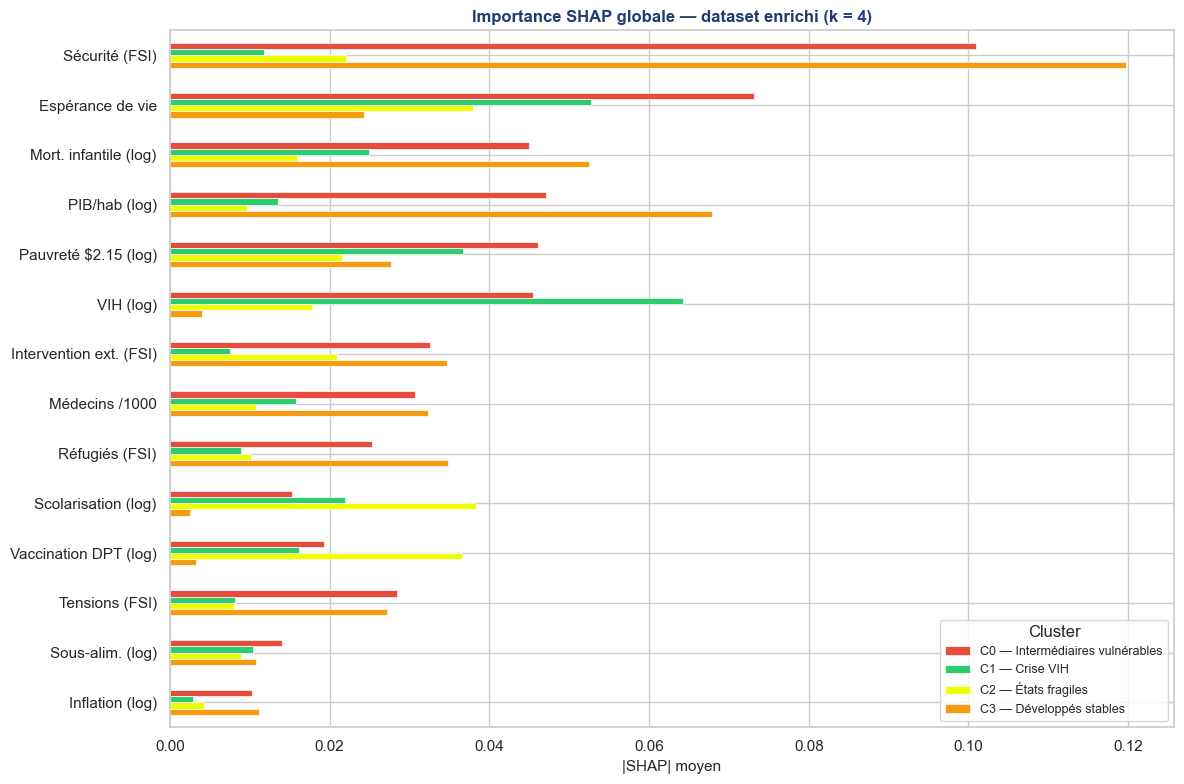


Variables les plus discriminantes (ordre décroissant) :
security_apparatus             0.0636
life_expec                     0.0470
child_mort_log                 0.0346
gdpp_log                       0.0345
social_poverty_2_15_log        0.0330
hiv_prevalence_log             0.0329
external_intervention          0.0239
physicians_per_1000            0.0224
refugees_idps                  0.0198
social_schooling_log           0.0195
vaccination_dpt_log            0.0188
group_grievance                0.0180
social_undernourishment_log    0.0110
inflation_log                  0.0071

--- Contribution des variables FSI (|SHAP| moyen) ---
security_apparatus       0.0636
external_intervention    0.0239
refugees_idps            0.0198
group_grievance          0.0180


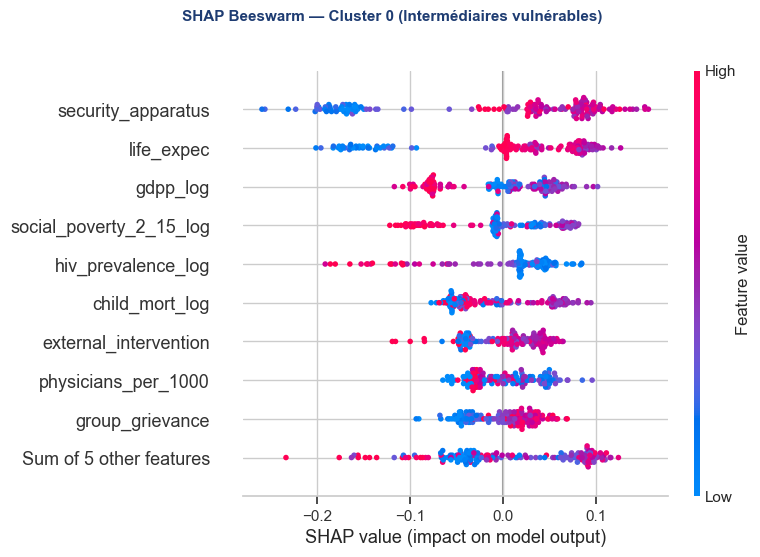

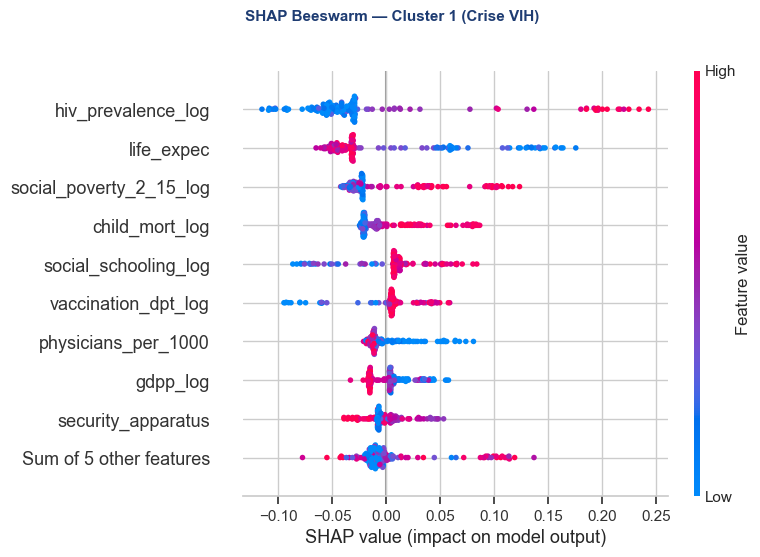

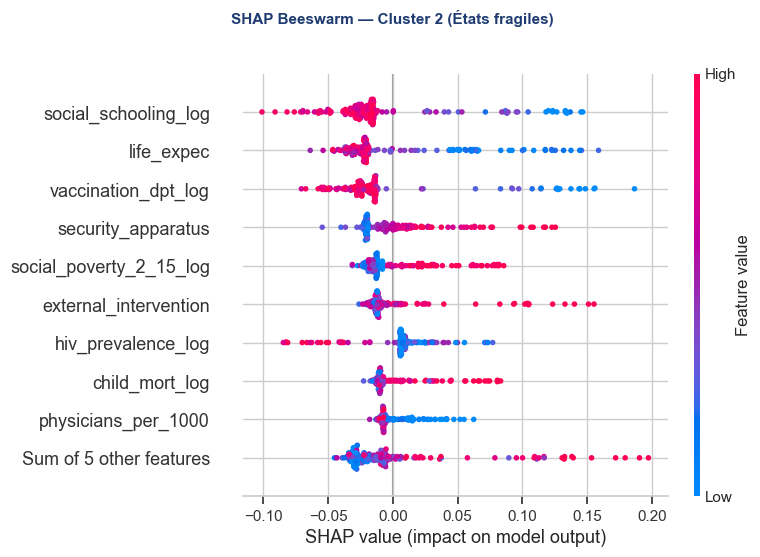

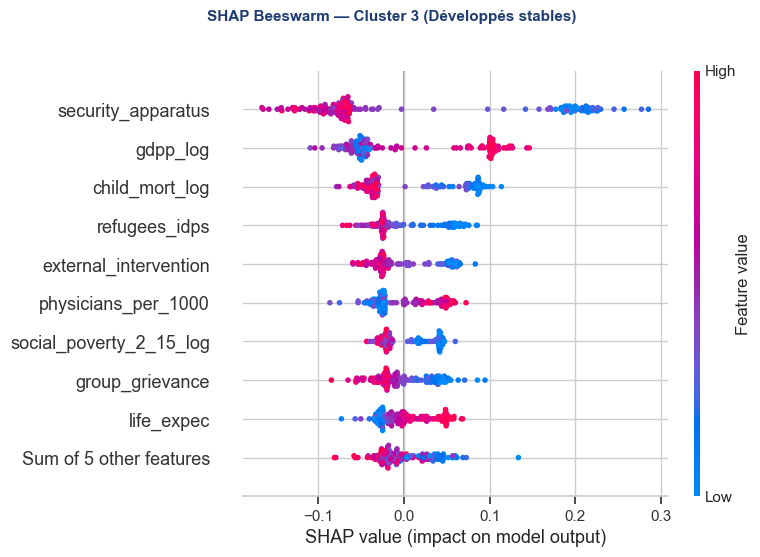

In [87]:
rf4 = RandomForestClassifier(n_estimators=300, max_depth=8,
                              random_state=SEED, n_jobs=-1)
rf4.fit(X4_sc, labels4)
acc4 = rf4.score(X4_sc, labels4)
print(f'Précision surrogat k=4 (train) : {acc4:.4f}')

explainer4 = shap.TreeExplainer(rf4)
exp4 = explainer4(X4_df)   # shape : (n_pays, n_features, n_clusters)

# -- Importance globale -------------------------------------------------------
shap_abs4 = np.abs(exp4.values).mean(axis=0)   # (n_features, K4)
df_imp4   = pd.DataFrame(
    shap_abs4,
    index=FEAT_K4,
    columns=[f'C{k} — {NAMES_K4[k]}' for k in sorted(NAMES_K4)]
)
df_imp4['mean'] = df_imp4.mean(axis=1)
df_imp4 = df_imp4.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
df_imp4.drop(columns='mean').rename(
    index={v: LABELS_K4[v].replace('\n', ' ') for v in LABELS_K4}
).plot(kind='barh', ax=ax,
       color=[PALETTE_K4[k] for k in sorted(NAMES_K4)],
       edgecolor='white', linewidth=0.5)
ax.set_xlabel('|SHAP| moyen', fontsize=11)
ax.set_title('Importance SHAP globale — dataset enrichi (k = 4)',
             fontsize=12, fontweight='bold', color='#1e3c72')
ax.invert_yaxis()
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.show()

print('\nVariables les plus discriminantes (ordre décroissant) :')
print(df_imp4['mean'].round(4).to_string())

# Mise en évidence des variables FSI
print('\n--- Contribution des variables FSI (|SHAP| moyen) ---')
fsi_vars = ['security_apparatus', 'group_grievance', 'refugees_idps', 'external_intervention']
print(df_imp4.loc[fsi_vars, 'mean'].sort_values(ascending=False).round(4).to_string())

# -- Beeswarm par cluster -----------------------------------------------------
for k in sorted(NAMES_K4):
    exp4_k = exp4[:, :, k]
    shap.plots.beeswarm(exp4_k, max_display=10, show=False)
    plt.gcf().suptitle(f'SHAP Beeswarm — Cluster {k} ({NAMES_K4[k]})',
                       fontsize=11, fontweight='bold', color='#1e3c72', y=1.01)
    plt.tight_layout()
    plt.show()

---
# Partie III : Comparaison inter-datasets

In [88]:
# -- Table des métriques -------------------------------------------------------
metrics = {
    'Métrique':          ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin',
                          'Variables', 'Clusters', 'Stabilité ARI (100 runs)'],
    'Classique (k = 3)': [f'{silhouette_score(X3_sc, labels3):.4f}',
                          f'{calinski_harabasz_score(X3_sc, labels3):.1f}',
                          f'{davies_bouldin_score(X3_sc, labels3):.4f}',
                          '8', '3', '0.9562'],
    'Enrichi (k = 4)':   [f'{silhouette_score(X4_sc, labels4):.4f}',
                          f'{calinski_harabasz_score(X4_sc, labels4):.1f}',
                          f'{davies_bouldin_score(X4_sc, labels4):.4f}',
                          '14', '4', '0.9655'],
    'Interprétation':    ['Enrichi supérieur (+21 %)',
                          'Enrichi supérieur (+18 %)',
                          'Enrichi supérieur (plus bas = meilleur)',
                          'Dimensions FSI + santé étendue ajoutées',
                          'Enrichi isole 2 sous-types de vulnérabilité',
                          'Enrichi légèrement plus stable'],
}
df_m = pd.DataFrame(metrics).set_index('Métrique')
display(df_m.style
        .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
        .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}]))

,Classique (k = 3),Enrichi (k = 4),Interprétation
Métrique,,,
Silhouette,0.2338,0.2840,Enrichi supérieur (+21 %)
Calinski-Harabasz,63.9,75.6,Enrichi supérieur (+18 %)
Davies-Bouldin,1.4153,1.1982,Enrichi supérieur (plus bas = meilleur)
Variables,8,14,Dimensions FSI + santé étendue ajoutées
Clusters,3,4,Enrichi isole 2 sous-types de vulnérabilité
Stabilité ARI (100 runs),0.9562,0.9655,Enrichi légèrement plus stable


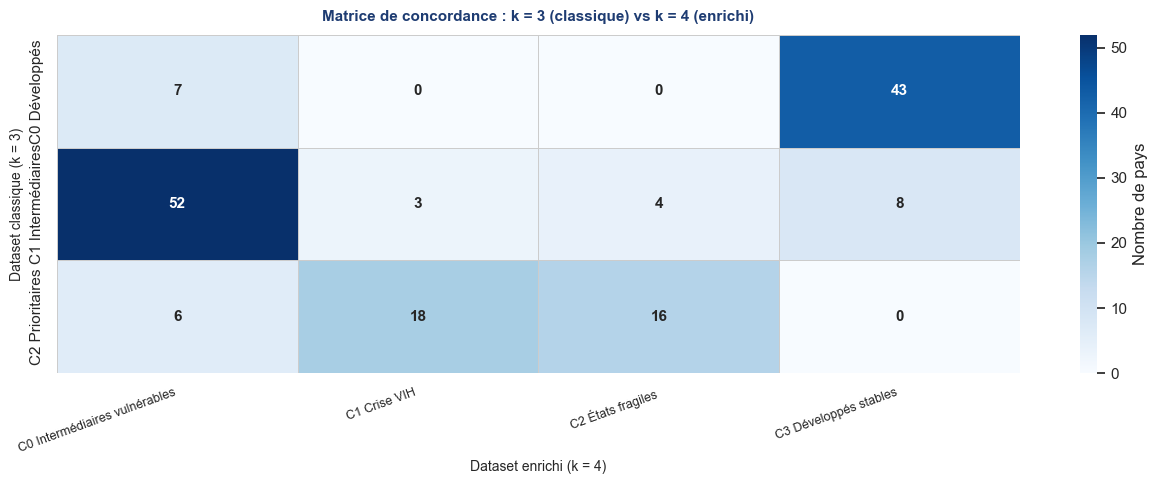

ARI inter-datasets : 0.4762
Pays appariés      : 157 / 167

Lecture : le cluster Prioritaires (k3) se scinde en deux clusters dans k4.

Scission du cluster Prioritaires (C2) :
  → C1 Crise VIH : 18 pays (45.0 %)
  → C2 États fragiles : 16 pays (40.0 %)
  → C0 Intermédiaires vulnérables : 6 pays (15.0 %)


In [89]:
# -- Matrice de concordance ---------------------------------------------------
merged = pd.merge(
    df3[['country', 'cluster']].rename(columns={'cluster': 'k3'}),
    df4[['country', 'cluster']].rename(columns={'cluster': 'k4'}),
    on='country', how='inner'
)

row_names = {k: f'C{k} {NAMES_K3[k]}' for k in NAMES_K3}
col_names = {k: f'C{k} {NAMES_K4[k]}' for k in NAMES_K4}

confusion = pd.crosstab(
    merged['k3'].map(row_names),
    merged['k4'].map(col_names),
    rownames=['Classique (k = 3)'],
    colnames=['Enrichi (k = 4)']
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='#cccccc', ax=ax,
            cbar_kws={'label': 'Nombre de pays'},
            annot_kws={'size': 11, 'fontweight': 'bold'})
ax.set_title('Matrice de concordance : k = 3 (classique) vs k = 4 (enrichi)',
             fontsize=11, fontweight='bold', color='#1e3c72', pad=10)
ax.set_xlabel('Dataset enrichi (k = 4)', fontsize=10)
ax.set_ylabel('Dataset classique (k = 3)', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

ari_inter = adjusted_rand_score(merged['k3'], merged['k4'])
print(f'ARI inter-datasets : {ari_inter:.4f}')
print(f'Pays appariés      : {len(merged)} / {len(df3)}')
print()
print('Lecture : le cluster Prioritaires (k3) se scinde en deux clusters dans k4.')
# Détail de la scission
pri_mask = merged['k3'] == pri3
reclasse = merged[pri_mask]['k4'].value_counts()
print(f'\nScission du cluster Prioritaires (C{pri3}) :')
for cid, cnt in reclasse.items():
    print(f'  → C{cid} {NAMES_K4[cid]} : {cnt} pays ({cnt/pri_mask.sum()*100:.1f} %)')

---
# Partie IV : Cartographie géographique

Les cartes choroplèthes visualisent la partition sur le globe. Le clustering est réalisé **sans aucune information de localisation géographique** : la cohérence spatiale observée : concentration des pays vulnérables en Afrique subsaharienne, des pays développés en Europe et Amérique du Nord constitue une validation externe de la pertinence des dimensions retenues.

Deux cartes sont présentées :
- **Carte k = 3** : vision globale tri-niveaux, aisément lisible
- **Carte k = 4** : vision opérationnelle, distingue crises VIH et conflits armés

In [ ]:

MAP_URL = 'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'

try:
    world = gpd.read_file(MAP_URL)
    print(f'Fond de carte chargé : {len(world)} entités')
except Exception as e:
    print(f'Impossible de charger le fond de carte : {e}')
    world = None

Fond de carte chargé : 177 entités


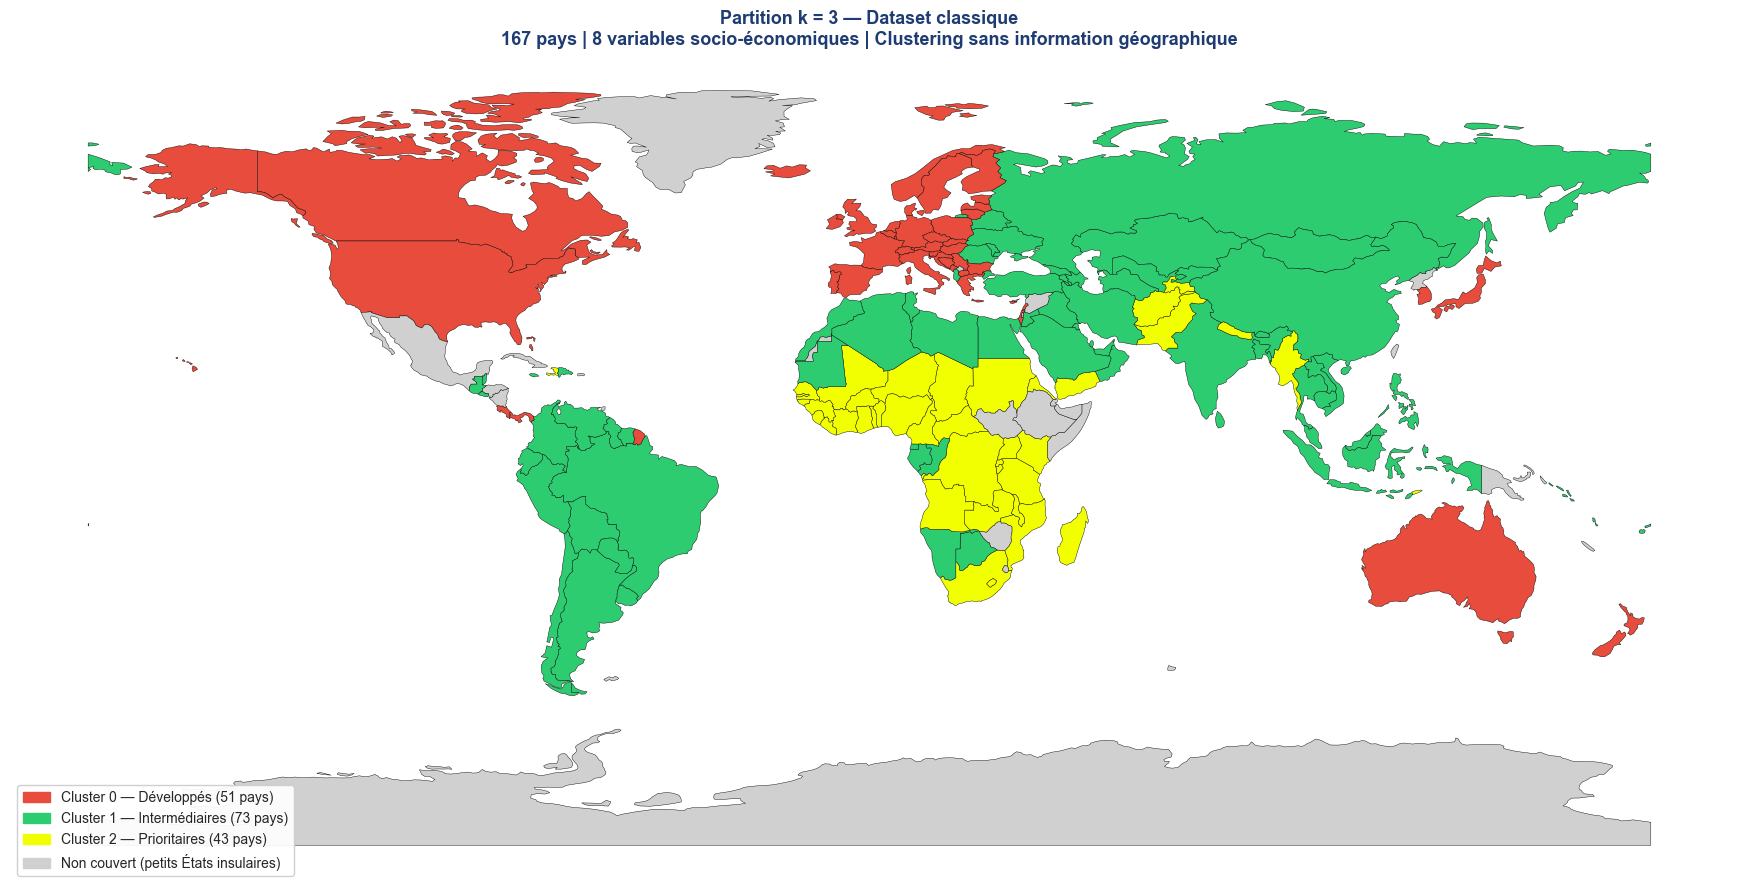

Pays sans correspondance cartographique (16) :
Antigua and Barbuda, Bahrain, Barbados, Cape Verde, Comoros, Grenada, Kiribati, Maldives, Malta, Mauritius, Micronesia, Fed. Sts., Samoa, Seychelles, Singapore, St. Vincent and the Grenadines, Tonga


In [91]:
if world is not None:
    df3_map = df3[['country', 'cluster']].copy()
    df3_map['country_ne'] = apply_ne_mapping(df3_map['country'], dataset='classic')
    df3_map['cluster_label'] = df3_map['cluster'].map(
        lambda x: f'Cluster {x} — {NAMES_K3[x]}'
    )

    world_k3 = world.merge(df3_map, left_on='ADMIN', right_on='country_ne', how='left')
    world_k3['cluster_label'] = world_k3['cluster_label'].fillna('Non couvert')

    color_map3 = {f'Cluster {k} — {NAMES_K3[k]}': PALETTE_K3[k] for k in sorted(NAMES_K3)}
    color_map3['Non couvert'] = GREY
    world_k3['color'] = world_k3['cluster_label'].map(color_map3)

    fig, ax = plt.subplots(figsize=(18, 9))
    world_k3.plot(color=world_k3['color'], edgecolor='black', linewidth=0.3, ax=ax)

    handles = [mpatches.Patch(color=PALETTE_K3[k],
                               label=f'Cluster {k} — {NAMES_K3[k]} ({(labels3==k).sum()} pays)')
               for k in sorted(NAMES_K3)]
    handles.append(mpatches.Patch(color=GREY, label='Non couvert (petits États insulaires)'))
    ax.legend(handles=handles, loc='lower left', fontsize=10, framealpha=0.92)
    ax.set_title(
        'Partition k = 3 — Dataset classique\n'
        '167 pays | 8 variables socio-économiques | Clustering sans information géographique',
        fontsize=13, fontweight='bold', color='#1e3c72'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Pays sans correspondance (petits États insulaires)
    matched = set(world_k3.dropna(subset=['cluster'])['country_ne'].tolist())
    unmatched = sorted(set(df3_map['country_ne'].tolist()) - matched)
    if unmatched:
        print(f'Pays sans correspondance cartographique ({len(unmatched)}) :')
        print(', '.join(unmatched))
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    pd.Series({f'C{k}\n{NAMES_K3[k]}': (labels3 == k).sum()
               for k in sorted(NAMES_K3)}).plot(
        kind='bar', ax=ax, color=[PALETTE_K3[k] for k in sorted(NAMES_K3)],
        edgecolor='white'
    )
    ax.set_ylabel('Nombre de pays')
    ax.set_title('Répartition k = 3', fontweight='bold', color='#1e3c72')
    plt.tight_layout()
    plt.show()

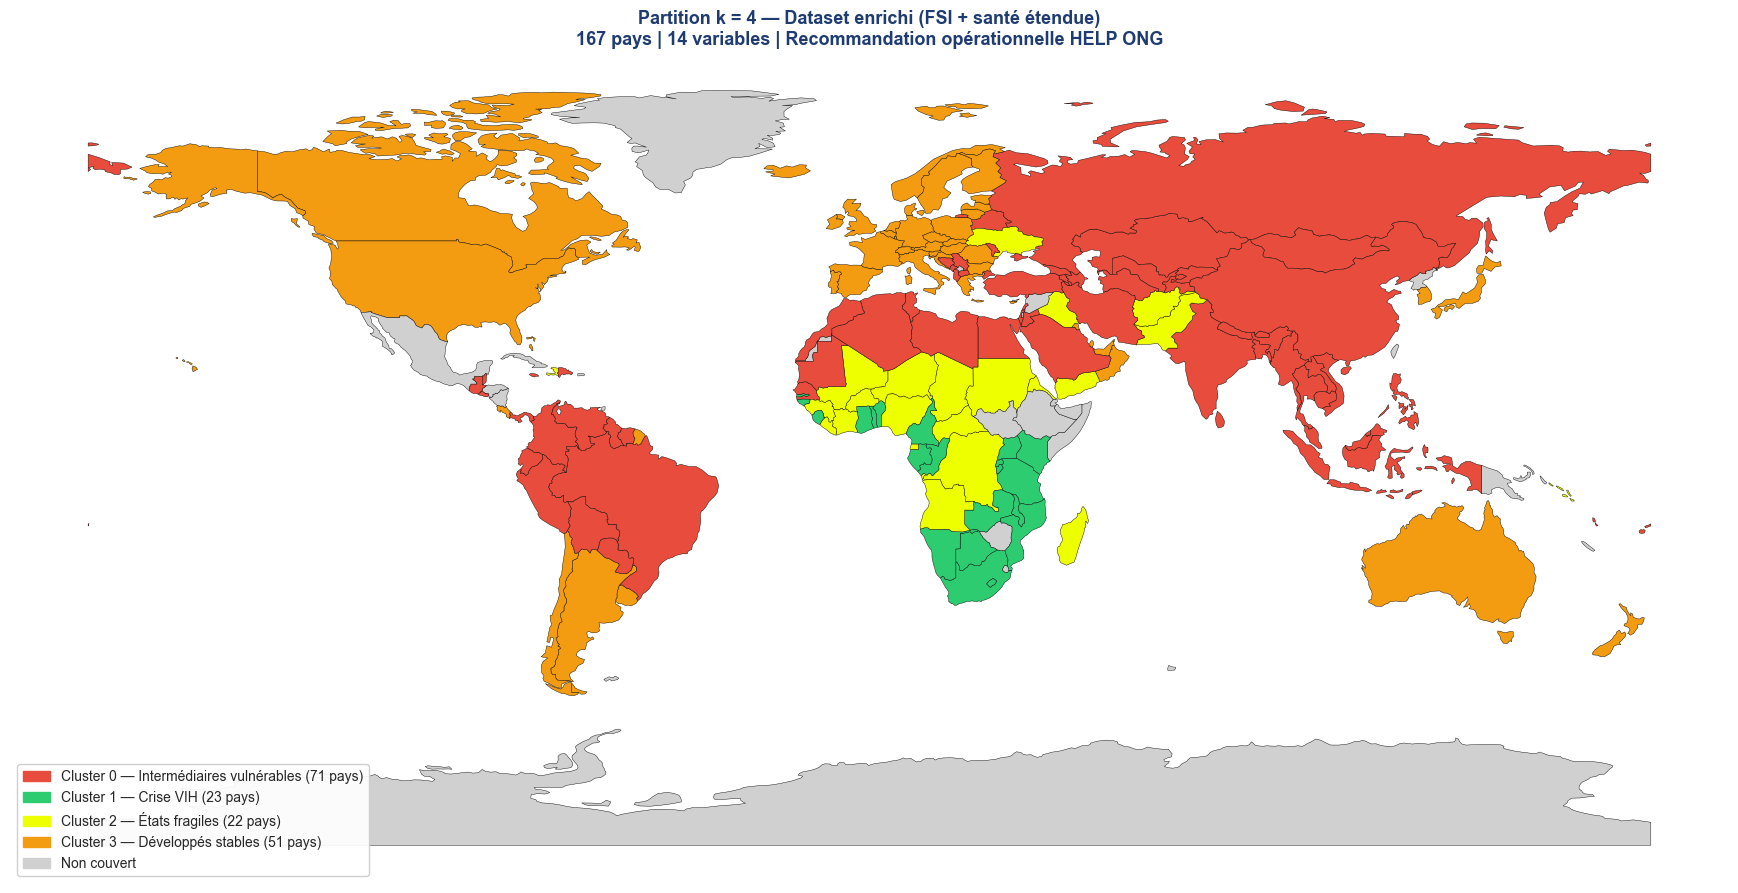

In [92]:
if world is not None:
    df4_map = df4[['country', 'iso_code', 'cluster']].copy()
    df4_map['cluster_label'] = df4_map['cluster'].map(
        lambda x: f'Cluster {x} — {NAMES_K4[x]}'
    )

    # Merge prioritaire sur code ISO-3 (ADM0_A3) — plus robuste que le nom
    world_k4 = world.merge(df4_map[['iso_code', 'cluster_label']],
                           left_on='ADM0_A3', right_on='iso_code', how='left')

    # Fallback sur nom ADMIN pour les pays sans correspondance ISO
    missing_mask = world_k4['cluster_label'].isna()
    if missing_mask.sum() > 0:
        df4_ne = df4_map.copy()
        df4_ne['country_ne'] = apply_ne_mapping(df4_ne['country'], dataset='enriched')
        world_k4_fb = world[missing_mask].merge(
            df4_ne[['country_ne', 'cluster_label']], left_on='ADMIN',
            right_on='country_ne', how='left'
        )
        world_k4.loc[missing_mask, 'cluster_label'] = world_k4_fb['cluster_label'].values

    world_k4['cluster_label'] = world_k4['cluster_label'].fillna('Non couvert')

    color_map4 = {f'Cluster {k} — {NAMES_K4[k]}': PALETTE_K4[k] for k in sorted(NAMES_K4)}
    color_map4['Non couvert'] = GREY
    world_k4['color'] = world_k4['cluster_label'].map(color_map4)

    fig, ax = plt.subplots(figsize=(18, 9))
    world_k4.plot(color=world_k4['color'], edgecolor='black', linewidth=0.3, ax=ax)

    handles = [mpatches.Patch(color=PALETTE_K4[k],
                               label=f'Cluster {k} — {NAMES_K4[k]} ({(labels4==k).sum()} pays)')
               for k in sorted(NAMES_K4)]
    handles.append(mpatches.Patch(color=GREY, label='Non couvert'))
    ax.legend(handles=handles, loc='lower left', fontsize=10, framealpha=0.92)
    ax.set_title(
        'Partition k = 4 — Dataset enrichi (FSI + santé étendue)\n'
        '167 pays | 14 variables | Recommandation opérationnelle HELP ONG',
        fontsize=13, fontweight='bold', color='#1e3c72'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    pd.Series({f'C{k}\n{NAMES_K4[k]}': (labels4 == k).sum()
               for k in sorted(NAMES_K4)}).plot(
        kind='bar', ax=ax, color=PALETTE_K4, edgecolor='white'
    )
    ax.set_ylabel('Nombre de pays')
    ax.set_title('Répartition k = 4', fontweight='bold', color='#1e3c72')
    plt.tight_layout()
    plt.show()

---
# Partie V Interprétation 

## Profilage qualitatif des clusters

L'interprétation finale traduit les profils statistiques en descriptions actionnables pour HELP ONG.

In [93]:
print('=== PROFILS BRUTS — DATASET CLASSIQUE (k = 3) ===\n')
display(
    m3_raw.rename(index={k: f'C{k} — {NAMES_K3[k]}' for k in NAMES_K3})
    .round(3)
    .style.background_gradient(cmap='RdYlGn', axis=0)
)

print('\n=== PROFILS BRUTS — DATASET ENRICHI (k = 4) ===\n')
display(
    m4_raw.rename(index={k: f'C{k} — {NAMES_K4[k]}' for k in NAMES_K4})
    .round(3)
    .style.background_gradient(cmap='RdYlGn', axis=0)
)

print('\n=== FOCUS FSI — SCORES PAR CLUSTER (k = 4) ===\n')
fsi_cols = ['security_apparatus', 'group_grievance', 'refugees_idps', 'external_intervention']
display(
    m4_raw[fsi_cols]
    .rename(index={k: f'C{k} — {NAMES_K4[k]}' for k in NAMES_K4})
    .rename(columns={'security_apparatus': 'Appareil sécuritaire',
                     'group_grievance': 'Tensions communautaires',
                     'refugees_idps': 'Réfugiés/déplacés',
                     'external_intervention': 'Intervention extérieure'})
    .round(3)
    .style.background_gradient(cmap='YlOrRd', axis=0)
)

=== PROFILS BRUTS — DATASET CLASSIQUE (k = 3) ===



,life_expec,child_mort_log,total_fer,gdpp_log,health,inflation_log,exports_log,imports_log
cluster,,,,,,,,
C0 — Développés,78.676000,1.911000,1.709000,10.026000,8.857000,0.681000,3.864000,3.910000
C1 — Intermédiaires,71.473000,3.179000,2.619000,8.483000,5.502000,2.187000,3.672000,3.716000
C2 — Prioritaires,59.367000,4.484000,4.976000,6.720000,6.624000,2.124000,2.984000,3.605000



=== PROFILS BRUTS — DATASET ENRICHI (k = 4) ===



,physicians_per_1000,hiv_prevalence_log,life_expec,child_mort_log,vaccination_dpt_log,gdpp_log,inflation_log,social_undernourishment_log,social_poverty_2_15_log,social_schooling_log,security_apparatus,group_grievance,refugees_idps,external_intervention
cluster,,,,,,,,,,,,,,
C0 — Intermédiaires vulnérables,1.566000,0.315000,72.218000,3.173000,4.527000,8.249000,2.008000,1.915000,1.712000,4.530000,6.585000,6.961000,5.309000,6.237000
C1 — Crise VIH,0.319000,1.828000,58.383000,4.368000,4.470000,7.061000,1.930000,2.849000,3.807000,4.488000,6.055000,5.921000,6.575000,7.105000
C2 — États fragiles,0.359000,0.637000,59.250000,4.460000,4.142000,6.934000,2.460000,2.810000,3.525000,4.238000,8.436000,7.882000,7.850000,8.545000
C3 — Développés stables,3.224000,0.253000,78.608000,1.931000,4.569000,10.175000,0.875000,1.345000,0.543000,4.559000,2.822000,4.288000,2.384000,3.039000



=== FOCUS FSI — SCORES PAR CLUSTER (k = 4) ===



,Appareil sécuritaire,Tensions communautaires,Réfugiés/déplacés,Intervention extérieure
cluster,,,,
C0 — Intermédiaires vulnérables,6.585000,6.961000,5.309000,6.237000
C1 — Crise VIH,6.055000,5.921000,6.575000,7.105000
C2 — États fragiles,8.436000,7.882000,7.850000,8.545000
C3 — Développés stables,2.822000,4.288000,2.384000,3.039000




### Cluster Développés stables 

**Profil** : PIB/hab élevé, espérance de vie > 76 ans, mortalité infantile très faible, scores FSI bas, densité médicale et scolarisation élevées. Les pays représentatifs sont les pays d'Europe occidentale, Amérique du Nord, Australie, Japon et pays du Golfe à hauts revenus.

**Position vis-à-vis de HELP ONG** : hors cible pour les programmes d'urgence ou de développement.
---

### Cluster Intermédiaires vulnérables

**Profil** : revenus intermédiaires-bas à intermédiaires-hauts, mortalité infantile modérée, fécondité modérée, scores FSI entre 5 et 7. On y trouve l'Amérique latine, l'Asie du Sud-Est, le Proche-Orient, l'Europe de l'Est et une partie de l'Afrique du Nord.

**Position vis-à-vis de HELP ONG** : programmes de coopération ciblés sur des gaps spécifiques (vaccination, accès aux soins primaires, scolarisation féminine). Horizon long terme, partenariat avec gouvernements locaux.

---

### Cluster Crise VIH

**Profil** : prévalence VIH nettement supérieure à toutes les autres régions (6 fois la moyenne mondiale), mortalité infantile élevée, espérance de vie réduite, scolarisation faible, scores FSI modérés (pas de conflit armé structurel). Pays représentatifs : Botswana, Lesotho, Zimbabwe, Zambie, Namibie, Kenya, Ouganda, Tanzanie.

**Géographie** : essentiellement l'Afrique australe et orientale.

**Position vis-à-vis de HELP ONG** : prioritaire comme le pays fragiles, mais type d'intervention radicalement différent. Terrain généralement accessible (stabilité institutionnelle relative).
 **Stratégie** : programmes VIH/SIDA , renforcement des systèmes de santé communautaires. Horizon moyen terme .

**Signal d'alerte opérationnel** : `hiv_prevalence_log` > 1.2

---

### Cluster États fragiles / Conflit armé

**Profil** : scores FSI très élevés , mortalité infantile très élevée, PIB/hab très faible, accès médical quasi inexistant. Pays représentatifs : Afghanistan, République centrafricaine, RD Congo, Somalie, Soudan du Sud, Tchad, Irak, Yémen, Haïti.

**Géographie** : Afrique sahélienne et centrale, Moyen-Orient en crise, Asie du Sud fragile.

**Position vis-à-vis de HELP ONG** : besoin humanitaire maximal, accessibilité terrain difficile. 
**Stratégie** : missions d'urgence courtes, logistique sécurisée, coordination étroite avec acteurs sécuritaires . Focus sur réduction de la mortalité immédiate (malnutrition, maladies évitables) et protection des populations déplacées. Horizon court terme , révision régulière selon évolution du conflit.

**Signal d'alerte opérationnel** : `security_apparatus` > 7.5 ou `refugees_idps` > 7.5 dans le modèle enrichi.

---

### Validation de l'hypothèse FSI

Si les scores SHAP de `security_apparatus` et `refugees_idps` sont parmi les plus élevés pour le cluster *États fragiles* , l'hypothèse centrale du projet est confirmée : l'enrichissement par les indicateurs FSI 2015 apporte une information opérationnelle que les seules données socio-économiques classiques ne permettaient pas de capturer.

## Tableau de synthèse décisionnel

| Cluster | Profil résumé | Priorité ONG | Type d'intervention | Horizon |
|---------|---------------|:------------:|---------------------|---------|
| Développés stables | PIB élevé, FSI bas, mortalité faible | Hors cible | Référence comparative | — |
| Intermédiaires vulnérables | PIB moyen, FSI modéré, accès soins partiel | Priorité 3 | Coopération ciblée, renforcement systèmes | Long terme |
| Crise VIH | Prévalence VIH >> moyenne, stabilité relative | Priorité 1 | ARV, prévention, systèmes communautaires | Moyen terme |
| États fragiles | FSI élevé, conflit, déplacements massifs | Priorité 1 | Urgence humanitaire, logistique sécurisée | Court terme |

---

### Recommandation finale

Le modèle enrichi (k = 4) est la recommandation opérationnelle de cette étude. Il surpasse le modèle classique sur toutes les métriques quantitatives et produit une segmentation directement exploitable pour la stratégie de déploiement de HELP ONG.

Le modèle classique (k = 3) conserve une utilité de robustesse : lorsque les données FSI ou épidémiologiques détaillées ne sont pas disponibles pour un nouveau pays.
.

---
# Conclusion

## Bilan du projet

Ce projet a démontré la faisabilité et la valeur opérationnelle d'une approche de clustering non supervisé pour soutenir la stratégie d'intervention de HELP ONG.

### Résultats clés

**Sur le plan méthodologique :**
- Le RobustScaler est justifié : les outliers (Luxembourg, Niger, Singapour) sont des réalités géo-économiques, non des erreurs ,les éliminer ou les neutraliser biaiserait l'analyse
- Le modèle  Random Forest + SHAP permet une interprétabilité rigoureuse .

**Sur le plan opérationnel :**
- Le dataset enrichi  **sépare deux types de vulnérabilité** que les données classiques confondaient : crise VIH (Afrique australe) et fragilité étatique/conflit (bande sahélienne, Moyen-Orient)
- Cette distinction est directement actionnelle : les interventions VIH  et les missions humanitaires en zone de conflit mobilisent des ressources, des compétences et des partenariats radicalement différents
- La cohérence géographique des clusters , obtenue sans aucune variable de localisation valide la pertinence des dimensions retenues

### Artefacts produits

| Fichier | Description |
|---------|-------------|
| `models/kmeans_k3_classique.joblib` | Modèle K-Means k = 3 sur dataset classique |
| `models/scaler_classique.joblib` | RobustScaler du dataset classique |
| `models/kmeans_k4_enrichi.joblib` | Modèle K-Means k = 4 sur dataset enrichi |
| `models/scaler_enrichi.joblib` | RobustScaler du dataset enrichi |
| `models/clusters_classique_k3.csv` | Labels finaux + features (167 pays) |
| `models/clusters_enrichi_k4.csv` | Labels finaux + iso_code + features (167 pays) |